In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [9]:
wine=load_wine()

In [22]:
print("Keys :",wine.keys)
print("Feature names:", wine['feature_names'])
print("Target names: ", wine['target_names'])
print("Shape of data: ",wine['data'].shape)
print("First 5 rows:\n", wine['data'][:5])
print("Target:\n", wine['target'])

Keys : <built-in method keys of Bunch object at 0x1103477a0>
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names:  ['class_0' 'class_1' 'class_2']
Shape of data:  (178, 13)
First 5 rows:
 [[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.

In [33]:
X_train,X_test,y_train,y_test=train_test_split(wine['data'],wine['target'],stratify=wine['target'],random_state=0)

print("X_train shape:", X_train.shape)   
print("X_test shape:", X_test.shape) 

X_train shape: (133, 13)
X_test shape: (45, 13)


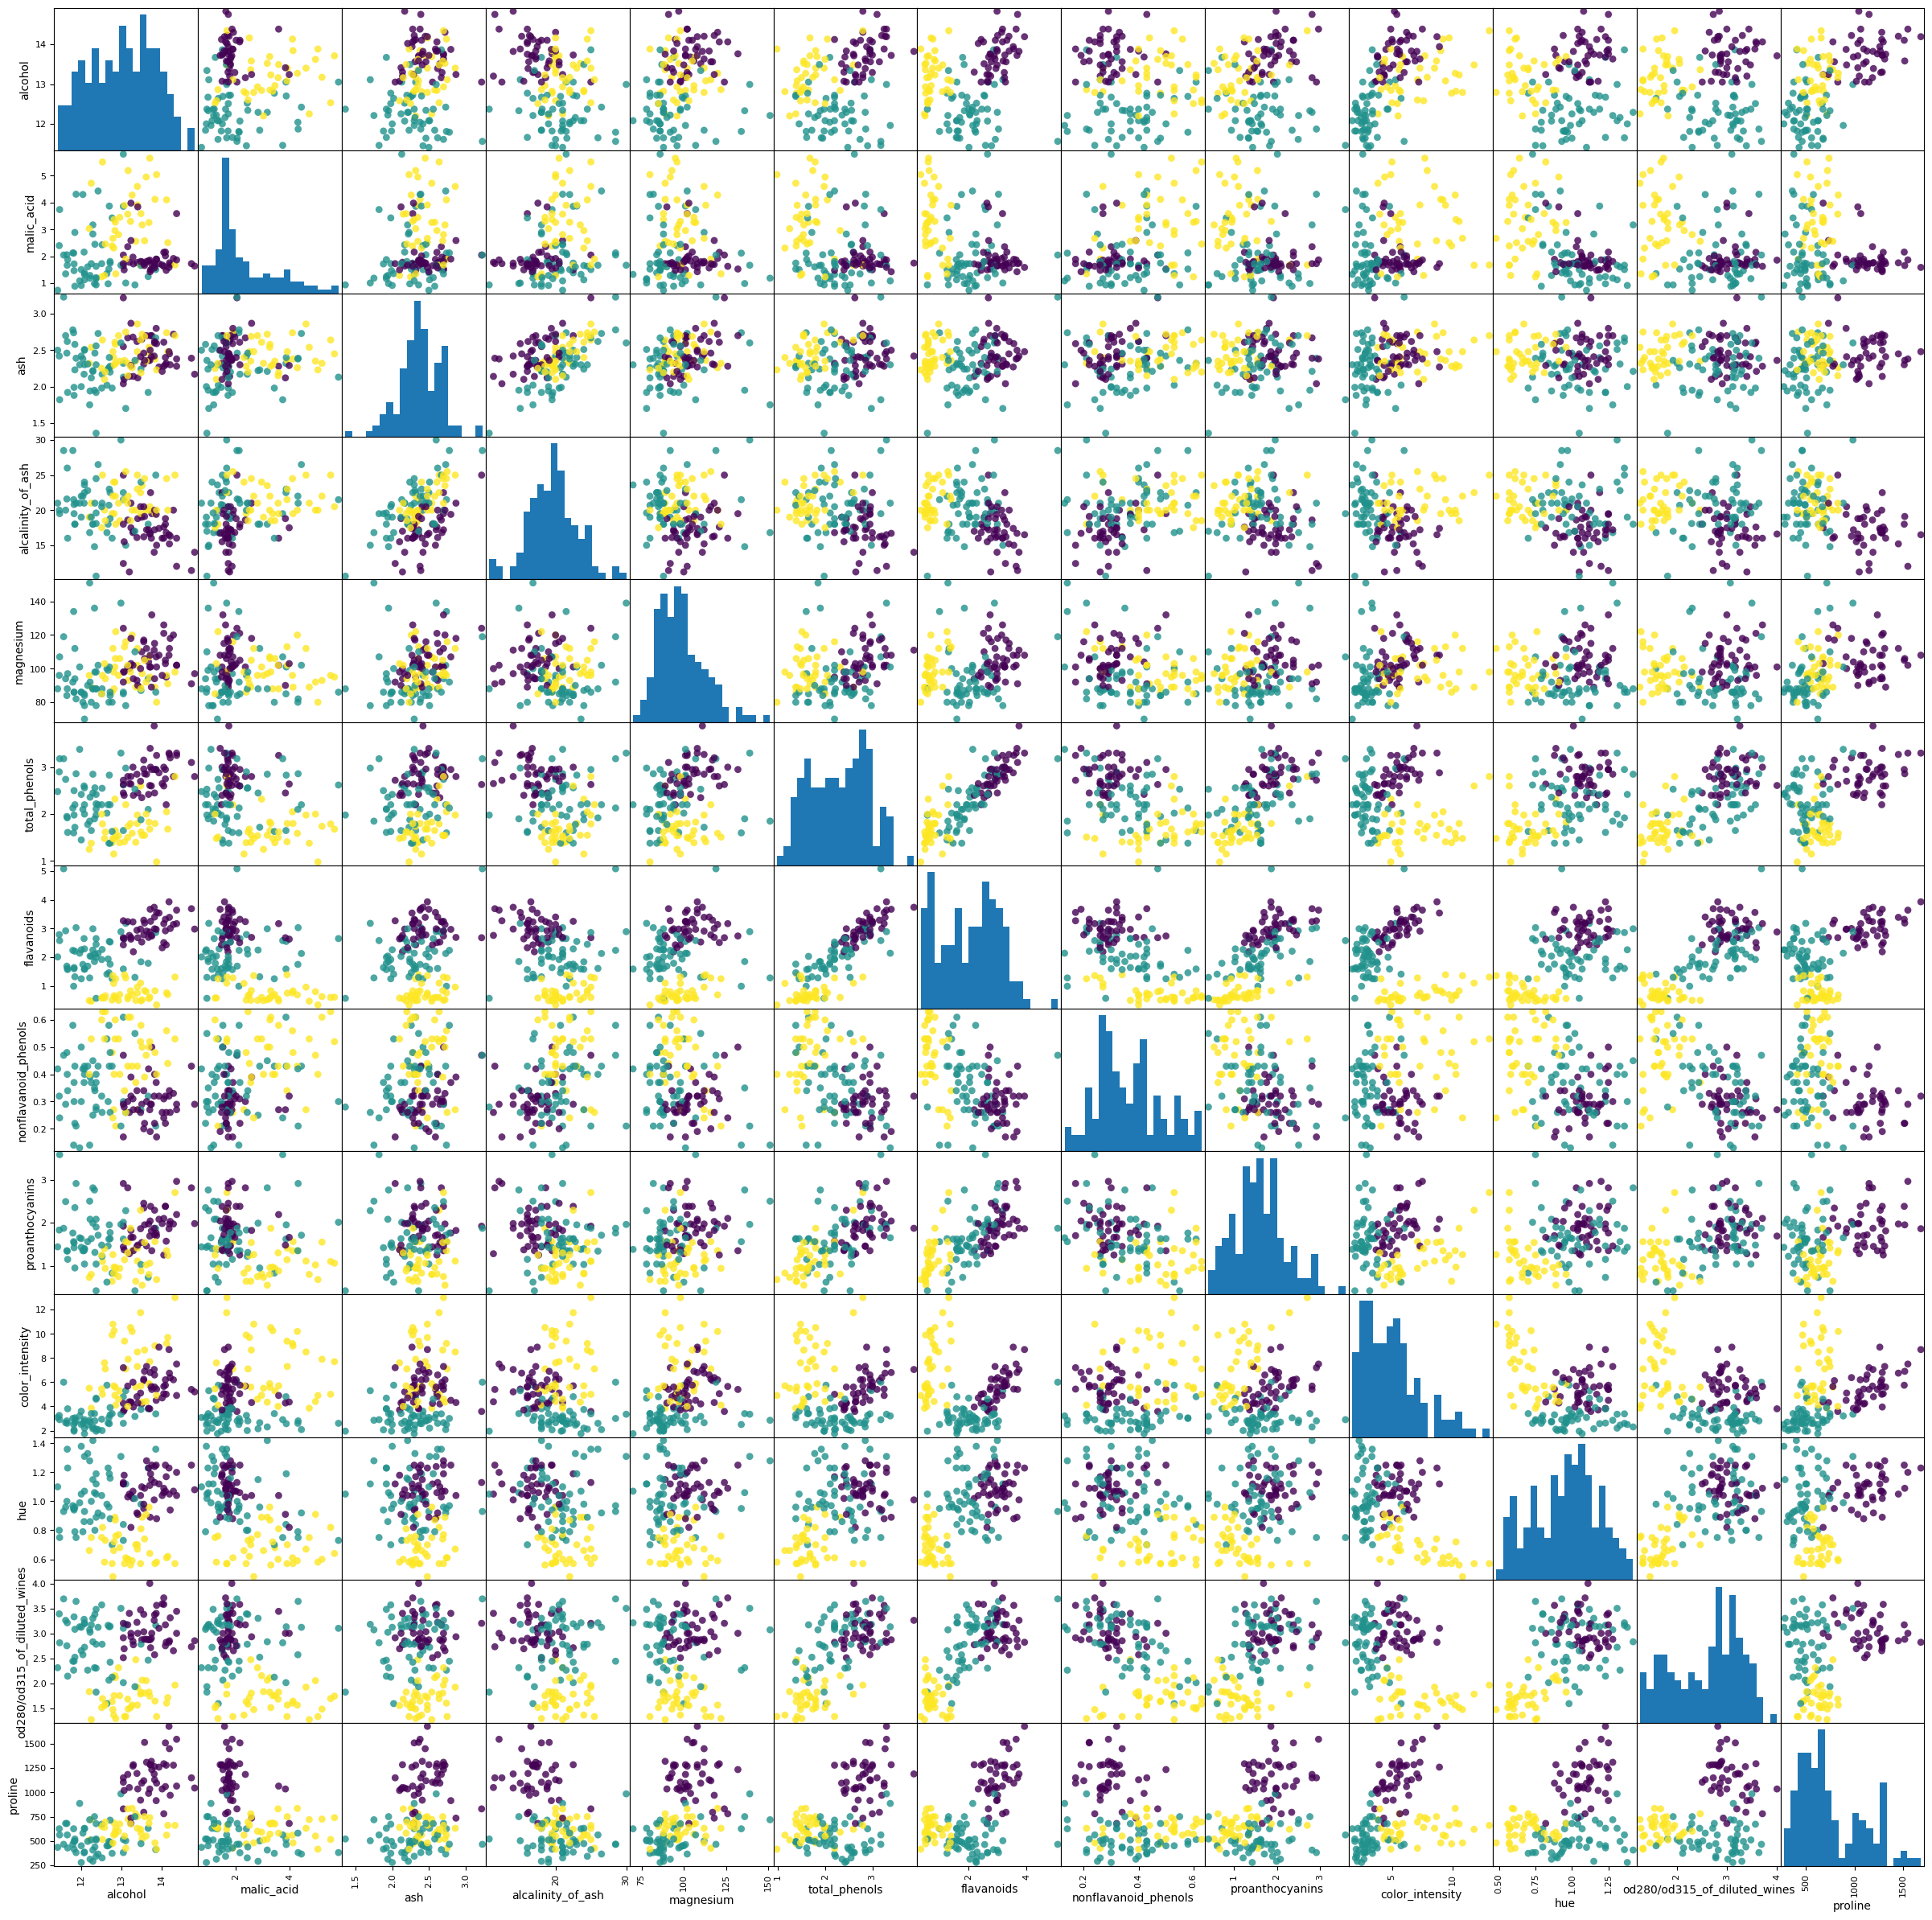

In [32]:
wine_df=pd.DataFrame(X_train, columns=wine.feature_names)
pd.plotting.scatter_matrix(wine_df, c=y_train, figsize=(30, 30), marker='o',
                           hist_kwds={'bins': 20}, s=40, alpha=.8)
plt.show()

In [34]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)               

y_pred = knn.predict(X_test)
print("Test predictions:", y_pred)

# Two ways to get accuracy
print("Accuracy (np.mean):  {:.2f}".format(np.mean(y_pred == y_test)))
print("Accuracy (.score):   {:.2f}".format(knn.score(X_test, y_test)))

Test predictions: [2 2 1 2 1 2 2 2 0 2 2 0 1 1 1 0 0 1 1 0 0 2 2 2 1 1 2 1 1 0 2 1 1 1 0 0 1
 1 1 1 1 1 0 1 1]
Accuracy (np.mean):  0.71
Accuracy (.score):   0.71


In [39]:
wrong = np.where(y_pred != y_test)[0]        # positions of the mistakes
for i in wrong:
    print(f"Wine {i}: guessed {y_pred[i]}, actually {y_test[i]}")

Wine 1: guessed 2, actually 0
Wine 3: guessed 2, actually 0
Wine 4: guessed 1, actually 2
Wine 10: guessed 2, actually 0
Wine 13: guessed 1, actually 2
Wine 14: guessed 1, actually 0
Wine 18: guessed 1, actually 2
Wine 25: guessed 1, actually 0
Wine 26: guessed 2, actually 1
Wine 27: guessed 1, actually 0
Wine 30: guessed 2, actually 1
Wine 34: guessed 0, actually 1
Wine 38: guessed 1, actually 2


In [40]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[ 9  3  3]
 [ 1 15  2]
 [ 0  4  8]]


In [43]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)               

y_pred = knn.predict(X_test)
print("Test predictions:", y_pred)

# Two ways to get accuracy
print("Accuracy (np.mean):  {:.2f}".format(np.mean(y_pred == y_test)))
print("Accuracy (.score):   {:.2f}".format(knn.score(X_test, y_test)))

Test predictions: [2 2 1 2 1 1 2 1 0 2 0 0 1 1 0 0 0 1 0 0 0 0 1 2 1 0 2 0 1 0 2 1 1 1 0 0 1
 1 1 1 0 1 0 1 1]
Accuracy (np.mean):  0.69
Accuracy (.score):   0.69
